# 1 Data Collection and Preparation

The raw taxi trip dataset consists of individual trip records. However, not every column is equally relevant for answering the business questions of the project. The final objective is not only to describe individual taxi trips, but to support a future ride-hailing fleet operator in understanding **where**, **when**, and under **which conditions** taxi demand occurs.

The latter includes implications for charging and repositioning an EV fleet. Answering these requires transforming the raw, trip-level dataset into an aggregated demand dataset (pickups per location unit and time bucket), evaluated across spatial and temporal resolutions. Sections 1.1 - 1.7 walk through this: 
- 1.1 Overview on the Dataset
- 1.2 Syntactical Cleaning
- 1.3 Missing Value Strategy
- 1.4 Semantic Validation
- 1.5 Feature Engineering, 
- 1.6 Spatial and Temporal Aggregation
- 1.7 Summary

## 1.1 Overview on dataset

Before cleaning, we take a first look at the raw data and check size, column types, and missing values per column. This determines which columns are usable and worth carrying forward into preparation.

In [1]:
import pandas as pd

df_full = pd.read_csv("../data/Taxi_Trips_(2024-)_20260502.csv")

df_full.head()


,Trip ID,Taxi ID,Trip Start Timestamp,Trip End Timestamp,Trip Seconds,Trip Miles,Pickup Census Tract,Dropoff Census Tract,Pickup Community Area,Dropoff Community Area,...,Extras,Trip Total,Payment Type,Company,Pickup Centroid Latitude,Pickup Centroid Longitude,Pickup Centroid Location,Dropoff Centroid Latitude,Dropoff Centroid Longitude,Dropoff Centroid Location
0,6c54cdb22905b181c23527e74c2b653a503107b7,db757f6c1157d9f81e266396132cd641837c189b803c52...,04/01/2026 12:00:00 AM,04/01/2026 12:15:00 AM,1.407,"14,35",NaN,NaN,76.0,22.0,...,"$5,00","$48,01",Credit Card,Flash Cab,"41,980264315","-87,913624596",POINT (-87.913624596 41.9802643146),"41,92276062","-87,699155343",POINT (-87.6991553432 41.9227606205)
1,6cd5d74b7ec8d7d230387900d72d74326dfb31de,f509c57d2f0b196f54d9b751ce2a1b6e956f378841b1e8...,04/01/2026 12:00:00 AM,04/01/2026 12:15:00 AM,1.701,"19,14",1.703198e+10,1.703132e+10,76.0,32.0,...,"$0,00","$60,50",Credit Card,City Service,"41,97907082","-87,903039661",POINT (-87.9030396611 41.9790708201),"41,884987192","-87,620992913",POINT (-87.6209929134 41.8849871918)
2,d36a90d961ed60add20ab3a4a7a8ca98bd2bf929,4136627ef25b9fad79910c55679c02d8e1f2a42925d29c...,04/01/2026 12:00:00 AM,04/01/2026 12:15:00 AM,1.260,"10,2",NaN,NaN,76.0,14.0,...,"$4,00","$31,25",Cash,Transit Administrative Center Inc,"41,980264315","-87,913624596",POINT (-87.913624596 41.9802643146),"41,968069","-87,721559063",POINT (-87.7215590627 41.968069)
3,cb1fed57e7eeea1db20758256b754201f5e13e07,c9bda81f1aaad786527911c983b6be11f28c6f46469e1a...,04/01/2026 12:00:00 AM,04/01/2026 12:30:00 AM,1.608,"18,4",NaN,NaN,76.0,32.0,...,"$5,00","$50,50",Credit Card,Taxicab Insurance Agency Llc,"41,980264315","-87,913624596",POINT (-87.913624596 41.9802643146),"41,878865584","-87,625192142",POINT (-87.6251921424 41.8788655841)
4,d3c33c166fdbca45d040772d18bd1ae1dc669ade,f71223a469d78a2f65a090adc9d4fb5ae08dfc6694c650...,04/01/2026 12:00:00 AM,04/01/2026 12:00:00 AM,422.000,"0,98",NaN,NaN,32.0,28.0,...,"$0,00","$6,00",Cash,Chicago Independents,"41,878865584","-87,625192142",POINT (-87.6251921424 41.8788655841),"41,874005383","-87,66351755",POINT (-87.6635175498 41.874005383)


In [2]:
df_full.info()

<class 'pandas.DataFrame'>
RangeIndex: 14802849 entries, 0 to 14802848
Data columns (total 23 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   Trip ID                     str    
 1   Taxi ID                     str    
 2   Trip Start Timestamp        str    
 3   Trip End Timestamp          str    
 4   Trip Seconds                float64
 5   Trip Miles                  str    
 6   Pickup Census Tract         float64
 7   Dropoff Census Tract        float64
 8   Pickup Community Area       float64
 9   Dropoff Community Area      float64
 10  Fare                        str    
 11  Tips                        str    
 12  Tolls                       str    
 13  Extras                      str    
 14  Trip Total                  str    
 15  Payment Type                str    
 16  Company                     str    
 17  Pickup Centroid Latitude    str    
 18  Pickup Centroid Longitude   str    
 19  Pickup Centroid Location    st

In [3]:
missing_overview = pd.DataFrame({
    "missing_count": df_full.isna().sum(),
    "missing_percent": df_full.isna().mean() * 100
})

missing_overview = missing_overview.sort_values(
    by="missing_count",
    ascending=False
)

missing_overview

,missing_count,missing_percent
Dropoff Census Tract,8435004,56.982301
Pickup Census Tract,8237431,55.647605
Dropoff Community Area,1320108,8.917932
Dropoff Centroid Longitude,1241359,8.385947
Dropoff Centroid Location,1241359,8.385947
Dropoff Centroid Latitude,1241359,8.385947
Pickup Community Area,413385,2.792604
Pickup Centroid Location,405819,2.741493
Pickup Centroid Latitude,405819,2.741493
Pickup Centroid Longitude,405819,2.741493


The table below summarizes each column's meaning, relevance for demand analysis, and missing-value share as the basis for deciding which columns to retain or exclude.

| Column | Meaning | Relevance | Missing Values (%) |
|---|---|---|---:|
| `Trip ID` | Unique identifier of each trip | Technical key, e.g. for detecting duplicates | 0.00 |
| `Taxi ID` | Anonymized identifier of the taxi | Vehicle-level analysis, idle time, vehicle utilization | 0.00 |
| `Trip Start Timestamp` | Start time of the trip, rounded to 15-minute intervals | Demand analysis by time, weekday, and calendar period | 0.00 |
| `Trip End Timestamp` | End time of the trip, rounded to 15-minute intervals | Trip duration validation, temporal pattern analysis | 0.00 |
| `Trip Seconds` | Duration of the trip in seconds | Travel time, speed calculation, outlier detection | 0.02 |
| `Trip Miles` | Distance of the trip in miles | Trip length, efficiency, cost-related analysis | 0.00 |
| `Pickup Census Tract` | Census tract where the trip starts | Fine-grained spatial demand analysis | 55.65 |
| `Dropoff Census Tract` | Census tract where the trip ends | Destination areas, mobility flows | 56.98 |
| `Pickup Community Area` | Community area of the pickup location | Coarser spatial demand analysis | 2.79 |
| `Dropoff Community Area` | Community area of the dropoff location | Destination patterns, origin-destination analysis | 8.92 |
| `Fare` | Base fare of the trip | Revenue analysis, price level | 0.21 |
| `Tips` | Tip amount | Payment and service behavior; less central for demand prediction | 0.21 |
| `Tolls` | Toll costs | Cost component, rather a control variable | 0.21 |
| `Extras` | Additional charges | Additional costs, e.g. airport-related fees | 0.21 |
| `Trip Total` | Total amount paid for the trip | Revenue per trip | 0.21 |
| `Payment Type` | Payment method, e.g. cash or credit card | User behavior, data quality checks | 0.00 |
| `Company` | Taxi company operating the trip | Provider structure, possible filtering variable | 0.00 |
| `Pickup Centroid Latitude` | Latitude of the pickup area centroid | Mapping, H3 hexagons, spatial modeling | 2.74 |
| `Pickup Centroid Longitude` | Longitude of the pickup area centroid | Mapping, H3 hexagons, spatial modeling | 2.74 |
| `Pickup Centroid Location` | Point coordinate of the pickup area centroid | GIS processing; redundant if latitude and longitude are used | 2.74 |
| `Dropoff Centroid Latitude` | Latitude of the dropoff area centroid | Destination hotspots, spatial destination analysis | 8.39 |
| `Dropoff Centroid Longitude` | Longitude of the dropoff area centroid | Destination hotspots, spatial destination analysis | 8.39 |
| `Dropoff Centroid Location` | Point coordinate of the dropoff area centroid | GIS processing; redundant if latitude and longitude are used | 8.39 |

**Takeaways from 1.1:**

- ~15M rows and most columns are complete. Missing values concentrate in spatial fields, especially in Pickup/ Dropoff Census Tract (~56%).
- Core columns for the demand dataset: pickup timestamp, pickup location (Community Area / Census Tract / coordinates), trip seconds/miles/total.
- Dropoff fields and `Taxi ID` are kept at the trip level for later OD- and idle-time analysis, but aren't required for the first aggregated demand dataset.
- Target variable going forward: `demand_count` = pickups per location unit × time bucket.


## 1.2 Syntactical Cleaning

This chapter focuses on technical data cleaning steps that are necessary before the dataset can be analyzed. The goal is to ensure that all columns have consistent formats and can be processed correctly.

The main steps include:

- standardizing column names
- converting timestamps into datetime format
- converting numeric and monetary columns into proper numeric types
- checking for duplicate rows

This step does not yet evaluate whether values are realistic in a business sense. It only ensures that the dataset is technically clean and usable.

In [4]:
# Standardize column names

df_full.columns = (
    df_full.columns
    .str.strip()                  
    .str.lower()                  
    .str.replace(" ", "_")        
)

df_full.columns

Index(['trip_id', 'taxi_id', 'trip_start_timestamp', 'trip_end_timestamp',
       'trip_seconds', 'trip_miles', 'pickup_census_tract',
       'dropoff_census_tract', 'pickup_community_area',
       'dropoff_community_area', 'fare', 'tips', 'tolls', 'extras',
       'trip_total', 'payment_type', 'company', 'pickup_centroid_latitude',
       'pickup_centroid_longitude', 'pickup_centroid_location',
       'dropoff_centroid_latitude', 'dropoff_centroid_longitude',
       'dropoff_centroid__location'],
      dtype='str')

The trip start and end timestamps are currently stored as raw values. Converting them into datetime format is necessary to extract time-based features such as hour, weekday, month, and different time buckets for later demand aggregation.

In [5]:
timestamp_cols = [
    "trip_start_timestamp",
    "trip_end_timestamp"
]

for col in timestamp_cols:
    df_full[col] = pd.to_datetime(df_full[col], errors="coerce")

df_full[timestamp_cols].dtypes

C:\Users\katig\AppData\Local\Temp\ipykernel_57416\1246117402.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_full[col] = pd.to_datetime(df_full[col], errors="coerce")
C:\Users\katig\AppData\Local\Temp\ipykernel_57416\1246117402.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_full[col] = pd.to_datetime(df_full[col], errors="coerce")


trip_start_timestamp    datetime64[us]
trip_end_timestamp      datetime64[us]
dtype: object

Several columns contain numeric values such as trip duration, trip distance, coordinates, and trip costs. These columns need to be stored as numeric data types to enable filtering, aggregation, outlier detection, and later modeling. Even if the values appear numeric in the raw CSV file, they may initially be imported as strings and should therefore be converted explicitly.

In [6]:
import gc

# trip_seconds: "1.407" -> 1407 (thousands separator is a dot)
df_full["trip_seconds"] = (
    df_full["trip_seconds"]
    .astype("string")
    .str.replace(".", "", regex=False)
    .pipe(pd.to_numeric, errors="coerce")
)

# decimal / monetary columns: "14,35" -> 14.35 and "$48,01" -> 48.01
num_cols = [
    "trip_miles", 
    "fare", 
    "tips", 
    "tolls", 
    "extras", 
    "trip_total",
    "pickup_centroid_latitude", 
    "pickup_centroid_longitude",
    "dropoff_centroid_latitude", 
    "dropoff_centroid_longitude",
]
for col in num_cols:
    df_full[col] = (
        df_full[col]
        .astype("string")
        .str.replace("$", "", regex=False)
        .str.replace(",", ".", regex=False)
        .pipe(pd.to_numeric, errors="coerce")
    )

# IDs / categories as strings
id_cols = [
    "trip_id", 
    "taxi_id",
    "pickup_census_tract", 
    "dropoff_census_tract",
    "pickup_community_area", 
    "dropoff_community_area",
    "payment_type", 
    "company",
]
for col in id_cols:
    df_full[col] = df_full[col].astype("string")

# Lossless memory shrink of df_full
# Done here, right after types are correct, so the WHOLE rest of the notebook
# operates on a smaller df_full. No values change:
#   - low-cardinality string columns -> category (codes + lookup, fully reversible)
#   - float64 -> float32 EXCEPT coordinates (kept full precision for H3 / GMM / KDE)
#   - downcast integers to the smallest exact type
# trip_id is NOT categorised (≈unique -> a category would only add overhead).
gc.collect()

cat_cols = ["taxi_id", "company", "payment_type",
            "pickup_census_tract", "dropoff_census_tract",
            "pickup_community_area", "dropoff_community_area"]
for col in cat_cols:
    df_full[col] = df_full[col].astype("category")

_keep_full = {"pickup_centroid_latitude", "pickup_centroid_longitude",
              "dropoff_centroid_latitude", "dropoff_centroid_longitude"}
for col in df_full.select_dtypes("float").columns:
    if col not in _keep_full:
        df_full[col] = pd.to_numeric(df_full[col], downcast="float")

gc.collect()
print(f"df_full memory: {df_full.memory_usage(deep=True).sum()/1e9:.2f} GB")
df_full.dtypes


df_full memory: 3.44 GB


trip_id                               string
taxi_id                             category
trip_start_timestamp          datetime64[us]
trip_end_timestamp            datetime64[us]
trip_seconds                           Int64
trip_miles                           Float32
pickup_census_tract                 category
dropoff_census_tract                category
pickup_community_area               category
dropoff_community_area              category
fare                                 Float32
tips                                 Float32
tolls                                Float32
extras                               Float32
trip_total                           Float32
payment_type                        category
company                             category
pickup_centroid_latitude             Float64
pickup_centroid_longitude            Float64
pickup_centroid_location                 str
dropoff_centroid_latitude            Float64
dropoff_centroid_longitude           Float64
dropoff_ce

Duplicate records can distort demand counts because the same trip would be counted more than once. Therefore, the dataset is checked for fully duplicated rows and duplicated trip IDs.

In [7]:
# Check fully duplicated rows
n_full_duplicates = df_full.duplicated().sum()

print(f"Number of fully duplicated rows: {n_full_duplicates}")

Number of fully duplicated rows: 0


In [8]:
# Check duplicated Trip IDs
n_duplicate_trip_ids = df_full["trip_id"].duplicated().sum()

print(f"Number of duplicated trip IDs: {n_duplicate_trip_ids}")

Number of duplicated trip IDs: 0


**Takeaways from 1.2:**

- Column names standardized to snake_case, timestamps are proper `datetime64`, numeric/monetary columns are correctly typed.
- No fully duplicated rows and no duplicated `trip_id`s, so no deduplication needed.
- The dataset is syntactically clean and remaining data-quality issues (missing and implausible values) are addressed next in 1.3 and 1.4.

## 1.3 Missing Value Strategy

Before checking the semantic plausibility of individual values, missing values are analyzed. Because the later demand dataset is created by aggregating trips across spatial and temporal units, and the missing values differ strongly across spatial columns, they must be handled per aggregation level. Dropping all rows with missing values globally would remove a large share of the dataset and could distort the observed demand patterns.

The actual removal of rows with missing values is therefore postponed until the corresponding aggregation dataset is created in 1.6.

In [9]:
# Check missing values overview again after type conversions
missing_overview = pd.DataFrame({
    "missing_count": df_full.isna().sum(),
    "missing_percent": df_full.isna().mean() * 100
})

missing_overview = missing_overview.sort_values(
    by="missing_count",
    ascending=False
)

missing_overview

,missing_count,missing_percent
dropoff_census_tract,8435004,56.982301
pickup_census_tract,8237431,55.647605
dropoff_community_area,1320108,8.917932
dropoff_centroid_longitude,1241359,8.385947
dropoff_centroid__location,1241359,8.385947
dropoff_centroid_latitude,1241359,8.385947
pickup_community_area,413385,2.792604
pickup_centroid_location,405819,2.741493
pickup_centroid_latitude,405819,2.741493
pickup_centroid_longitude,405819,2.741493


After syntactical cleaning, most missing value counts remain unchanged. Only a few numeric columns such as `trip_total`, `fare`, `extras`, `tolls`, and `trip_miles` show a small increase in missing values, likely caused by non-convertible values being coerced to `NaN`. The spatial missing value pattern remains unchanged.

| Column       | before | after   | difference  |
| ------------ | -----: | ------: | ----------: |
| `trip_total` | 31,160 |  32,943 |      +1,783 |
| `fare`       | 31,160 |  32,894 |      +1,734 |
| `extras`     | 31,160 |  31,198 |         +38 |
| `tolls`      | 31,160 |  31,174 |         +14 |
| `trip_miles` |    123 |     139 |         +16 |


- **Census Tract:** more than half missing (Chicago suppresses it for privacy) --> not suitable as the main spatial unit.
- **Community Area:** only 2.79% missing --> suitable as the baseline spatial unit.
- **Pickup coordinates:** ~2.74% missing --> usable for H3/hexagon units. However, they should be interpreted as approximate area centroids, not exact pickup locations.
- **Dropoff fields:** more missing than pickup fields, but since the demand model focuses on where trips start, dropoff missing values should not be used to remove observations from the main demand dataset.

In [10]:
# missing values focused on pickup data
spatial_missing = missing_overview.loc[
    [
        "pickup_census_tract",
        "pickup_community_area",
        "pickup_centroid_latitude",
        "pickup_centroid_longitude"
    ]
]

spatial_missing

,missing_count,missing_percent
pickup_census_tract,8237431,55.647605
pickup_community_area,413385,2.792604
pickup_centroid_latitude,405819,2.741493
pickup_centroid_longitude,405819,2.741493


In [11]:
# Missingness flag for baseline spatial unit
missing_pickup_area = df_full["pickup_community_area"].isna()

# Helper function
def missing_rate_by(group_col, missing_flag):
    return (
        df_full
        .assign(missing=missing_flag)
        .groupby(group_col)["missing"]
        .agg(["count", "sum", "mean"])
        .rename(columns={
            "count": "total_trips",
            "sum": "missing_count",
            "mean": "missing_percent"
        })
        .assign(missing_percent=lambda x: x["missing_percent"] * 100)
        .sort_values("missing_percent", ascending=False)
    )

In [12]:
missing_area_by_company = missing_rate_by("company", missing_pickup_area)

missing_area_by_company.head(15)

,total_trips,missing_count,missing_percent
company,,,
4623 - 27290 Jay Kim,2156,2156,100.000000
4787 - 56058 Reny Cab Co,83,83,100.000000
Tac - American United Non Dispatch,21,11,52.380952
Tac - American United Dispatch,18031,5679,31.495757
Blue Ribbon Taxi Association Inc.,21,4,19.047619
Tac - Blue Diamond Non Dispatch,309,52,16.828479
Chicago City Taxi Association,128820,21355,16.577395
Tac - Blue Diamond Dispatch,5701,825,14.471145
Tac - Yellow Non Color,5748,769,13.378566


The highest missing rates occur mostly for small companies, where percentages are unstable because they are based on few trips. Some larger companies also show above-average missing rates, but the affected rows still represent only a small share of the full dataset. Therefore, we do not exclude companies entirely. For the baseline Community Area dataset, only rows with missing `pickup_community_area` are removed later.

In [13]:
missing_area_by_hour = (
    df_full
    .assign(
        hour=df_full["trip_start_timestamp"].dt.hour,
        missing=missing_pickup_area
    )
    .groupby("hour")["missing"]
    .agg(["count", "sum", "mean"])
    .rename(columns={
        "count": "total_trips",
        "sum": "missing_count",
        "mean": "missing_percent"
    })
)

missing_area_by_hour["missing_percent"] *= 100

missing_area_by_hour

,total_trips,missing_count,missing_percent
hour,,,
0,234351,8825,3.765719
1,137321,6054,4.408648
2,80887,3688,4.559447
3,62952,2969,4.716292
4,81488,5583,6.851316
5,143511,7357,5.126436
6,281914,9034,3.204523
7,544657,22000,4.039239
8,798324,28151,3.526263


Missing `pickup_community_area` values vary slightly by hour, with somewhat higher rates during the early morning hours. However, the differences are moderate and there is no extreme hourly concentration. Therefore, the missing values do not appear to strongly distort the temporal demand pattern.

In [14]:
missing_area_by_month = (
    df_full
    .assign(
        month=df_full["trip_start_timestamp"].dt.month,
        missing=missing_pickup_area
    )
    .groupby("month")["missing"]
    .agg(["count", "sum", "mean"])
    .rename(columns={
        "count": "total_trips",
        "sum": "missing_count",
        "mean": "missing_percent"
    })
)

missing_area_by_month["missing_percent"] *= 100

missing_area_by_month

,total_trips,missing_count,missing_percent
month,,,
1,1313121,39557,3.012441
2,1340039,39418,2.941556
3,1670264,45684,2.735136
4,1124241,32366,2.878920
5,1271845,35031,2.754345
6,1254541,31187,2.485929
7,1135646,29893,2.632246
8,1149340,30724,2.673186
9,1186885,33938,2.859418


Missing `pickup_community_area` rates are very similar across months, ranging from about 2.49% to 3.01%. Therefore, removing these rows is unlikely to skew the monthly distribution of trips.

In [15]:
trip_characteristics_by_missing_area = (
    df_full
    .assign(missing_pickup_area=missing_pickup_area)
    .groupby("missing_pickup_area")[["trip_seconds", "trip_miles", "trip_total"]]
    .agg(["count", "mean", "median"])
)

trip_characteristics_by_missing_area

trip_seconds                      trip_miles            \
                           count         mean  median      count      mean   
missing_pickup_area                                                          
False                   14386873  3419.749384  2630.0   14389352   6.53513   
True                      413129  2297.570735  1282.0     413358  6.478296   

                           trip_total                        
                    median      count       mean     median  
missing_pickup_area                                          
False                 3.04   14357822  26.935566  17.469999  
True                   1.6     412084  36.428352       29.0

Trips with missing `pickup_community_area` differ somewhat from complete trips: they have shorter durations and lower median distances, but a higher average and median `trip_total`. However, since only 2.79% of trips are affected, removing them for the Community Area dataset is acceptable and unlikely to strongly distort the overall demand counts.

In [16]:
# Quantify how many rows remain usable per planned aggregation dataset

required_cols = {
    "Community Area × time": ["pickup_community_area", "trip_start_timestamp"],
    "H3 / hexagon × time":   ["pickup_centroid_latitude", "pickup_centroid_longitude", "trip_start_timestamp"],
    "Census Tract × time":   ["pickup_census_tract", "trip_start_timestamp"],
}

n_total = len(df_full)

usability = pd.DataFrame(
    [
        {
            "dataset": name,
            "required_columns": ", ".join(cols),
            "usable_rows": df_full[cols].dropna().shape[0],
            "usable_percent": df_full[cols].dropna().shape[0] / n_total * 100,
            "lost_percent": (1 - df_full[cols].dropna().shape[0] / n_total) * 100,
        }
        for name, cols in required_cols.items()
    ]
)

usability

,dataset,required_columns,usable_rows,usable_percent,lost_percent
0,Community Area × time,"pickup_community_area, trip_start_timestamp",14389464,97.207396,2.792604
1,H3 / hexagon × time,"pickup_centroid_latitude, pickup_centroid_long...",14397030,97.258507,2.741493
2,Census Tract × time,"pickup_census_tract, trip_start_timestamp",6565418,44.352395,55.647605


In [17]:
pd.crosstab(
    df_full["pickup_community_area"].isna(),
    df_full["pickup_centroid_latitude"].isna(),
    margins=True
)

pickup_centroid_latitude,False,True,All
pickup_community_area,,,
False,14389464,0,14389464
True,7566,405819,413385
All,14397030,405819,14802849


**Takeaways from 1.3:**

- Baseline spatial units: `pickup_community_area` (2.79% missing) and pickup coordinates (2.74% missing). Their missingness co-occurs almost entirely (only 7,566 rows (0.05%) have one but not the other). `pickup_census_tract` (55.6% missing) is not used as a primary unit.
- Missingness in `pickup_community_area` is not meaningfully concentrated by hour or month, and affected trips are only slightly shorter/cheaper, so dropping them later is safe and won't distort demand patterns.
- Usable rows if filtered now: Community Area 97.2%, H3 97.3%, Census Tract 44.4%, therefore Census Tract is used only as a sensitivity check, not for absolute demand levels.
- No rows are dropped yet. Filtering is applied per dataset in 1.6.

## 1.4 Semantic Validation and Outlier Handling

Next, the available values are checked for plausibility from a business perspective. Negative durations, zero distances, or extreme totals could distort demand aggregation and model training. Checks are only performed where the required values are available, consistent with the missing value strategy from 1.3.

Each check below inspects a specific field or relationship and, where appropriate, defines a boolean flag. Flags are not applied here, they're only combined and used as filters in 1.6.

In [18]:
# Check chronological order of timestamps
invalid_order = df_full["trip_end_timestamp"] < df_full["trip_start_timestamp"]

n_invalid = invalid_order.sum()
pct_invalid = invalid_order.mean() * 100

print(f"Rows where end < start: {n_invalid} ({pct_invalid:.4f}%)")


Rows where end < start: 98 (0.0007%)


In [19]:
# Flag rows where trip end is before trip start: clear recording error
# Applied as a hard exclusion in 1.6
end_before_start = df_full["trip_end_timestamp"] < df_full["trip_start_timestamp"]

df_full.loc[end_before_start, [
    "trip_start_timestamp", "trip_end_timestamp", 
    "trip_seconds", "trip_miles", "trip_total"]]

,trip_start_timestamp,trip_end_timestamp,trip_seconds,trip_miles,trip_total
464409,2026-03-08 00:45:00,2026-03-06 07:45:00,<NA>,38.400002,121.349998
730653,2026-02-20 05:30:00,2026-02-17 08:15:00,<NA>,1.8,9.75
822429,2026-02-14 00:00:00,2026-02-11 09:15:00,<NA>,22.5,56.0
1627737,2025-12-21 02:45:00,2025-12-20 13:30:00,<NA>,2.4,12.0
2067908,2025-11-29 20:15:00,2025-11-05 21:00:00,<NA>,15.1,49.450001
...,...,...,...,...,...
13886367,2024-03-04 18:00:00,2024-03-04 15:45:00,<NA>,12.1,43.25
14319785,2024-02-05 11:30:00,2024-02-05 11:15:00,<NA>,0.0,7.75
14675961,2024-01-11 09:00:00,2024-01-11 08:00:00,<NA>,1.6,11.75
14677062,2024-01-11 08:00:00,2024-01-11 07:00:00,<NA>,1.4,10.0


All 98 affected rows have trip_seconds = NaN and show timestamp differences ranging from one hour to several days. This is a consistent pattern indicating systematic recording errors, not short valid trips. 

In [20]:
# Distribution of trip_seconds and edge case counts
print(df_full["trip_seconds"].describe(percentiles=[.25, .5, .75, .95, .99, .999]))
print()
print(f"Zero (= 0): {(df_full['trip_seconds'] == 0).sum()}")
print(f"Negative (< 0): {(df_full['trip_seconds'] < 0).sum()}")
print(f"> 2h (7 200 s): {(df_full['trip_seconds'] > 7_200).sum()}")
print(f"> 3h (10 800 s): {(df_full['trip_seconds'] > 10_800).sum()}")

count     14800002.0
mean     3388.424757
std      2991.053106
min              0.0
25%           1199.0
50%           2578.0
75%           5400.0
95%           8820.0
99%           9710.0
99.9%         9990.0
max          86396.0
Name: trip_seconds, dtype: Float64

Zero (= 0): 201927
Negative (< 0): 0
> 2h (7 200 s): 1895855
> 3h (10 800 s): 12104


In [21]:
#Zero or negative trip_seconds: clear recording errors
invalid_seconds = df_full["trip_seconds"] <= 0

# Extremely long trips (> 3 hours): inspect before deciding on exclusion
extreme_seconds = df_full["trip_seconds"] > 10_800

print(f"invalid_seconds (≤ 0): {invalid_seconds.sum()} rows ({invalid_seconds.mean()*100:.4f}%)")
print(f"extreme_seconds (> 3h): {extreme_seconds.sum()} rows ({extreme_seconds.mean()*100:.4f}%)")

# Inspect extreme trips
df_full.loc[extreme_seconds, ["trip_start_timestamp", "trip_seconds", "trip_miles", "trip_total"]].describe()

invalid_seconds (≤ 0): 201927 rows (1.3644%)
extreme_seconds (> 3h): 12104 rows (0.0818%)


,trip_start_timestamp,trip_seconds,trip_miles,trip_total
count,12104,12104.0,12097.0,12036.0
mean,2025-02-12 18:15:24.314276,36106.062541,19.36577,67.97303
min,2024-01-01 03:00:00,10801.0,0.0,0.0
25%,2024-08-03 16:26:15,14662.75,1.29,10.75
50%,2025-02-16 14:15:00,35301.5,9.69,37.25
75%,2025-08-20 06:18:45,52999.25,20.540001,82.25
max,2026-03-31 23:00:00,86396.0,786.330017,985.0
std,NaN,21114.531822,38.394909,103.671455


No negatives exist, but there are zero-second trips (201,927, ~1.36%). The distribution is clean up to the 99.9th percentile. Above 3 hours only 12,104 rows (0.08%) remain, with a median of ~9.8 h, a max distance of 786 miles, and a max trip_total of $985. These are most likely not real taxi trips and are captured in extreme_seconds and potentially excluded in section 1.6.

In [22]:
# Trip Distance (trip_miles)
print(df_full["trip_miles"].describe(percentiles=[.25, .5, .75, .95, .99, .999]))
print()
print(f"Zero (= 0): {(df_full['trip_miles'] == 0).sum()}")
print(f"Negative (< 0): {(df_full['trip_miles'] < 0).sum()}")
print(f"> 50 miles: {(df_full['trip_miles'] > 50).sum()}")
print(f"> 100 miles: {(df_full['trip_miles'] > 100).sum()}")

zero_miles = df_full["trip_miles"] == 0
extreme_miles = df_full["trip_miles"] > 100

print()
print(f"zero_miles: {zero_miles.sum()} rows ({zero_miles.mean()*100:.2f}%)")
print(f"extreme_miles (> 100 mi): {extreme_miles.sum()} rows ({extreme_miles.mean()*100:.4f}%)")

count    14802710.0
mean       6.533543
std        7.240746
min             0.0
25%            1.07
50%            3.02
75%            11.6
95%       18.309999
99%           26.73
99.9%         42.48
max      979.169983
Name: trip_miles, dtype: Float64

Zero (= 0): 1294820
Negative (< 0): 0
> 50 miles: 7187
> 100 miles: 1202

zero_miles: 1294820 rows (8.75%)
extreme_miles (> 100 mi): 1202 rows (0.0081%)


No negative distances exist. Zero-mile trips (1,294,820, ~8.75%) likely reflect metering issues or canceled trips. They still count as pickup demand events but are excluded from any distance- or speed-based feature calculations. Trips above 100 miles (1,202 rows, max 979 miles) are likely recording errors consistent with the extreme_seconds group and are captured in extreme_miles for exclusion in section 1.6.

In [23]:
# Cross-check: zero-mile trips: are trip_seconds also low or is there a discrepancy?
mask = df_full["trip_miles"] == 0
print("trip_seconds for zero-mile trips:")
print(df_full.loc[mask, "trip_seconds"].describe(percentiles=[.5, .75, .95, .99]))
print()
zero_miles_long = mask & (df_full["trip_seconds"] > 1_200)
print(f"zero miles BUT > 20 min duration: {zero_miles_long.sum()} rows ({zero_miles_long.mean()*100:.2f}%)")

trip_seconds for zero-mile trips:
count      1293385.0
mean     1521.194978
std       2889.04301
min              0.0
50%            160.0
75%           1800.0
95%           7570.0
99%           9560.0
max          86396.0
Name: trip_seconds, dtype: Float64

zero miles BUT > 20 min duration: 373910 rows (2.53%)


The median trip_seconds for zero-mile trips is 160 s, consistent with short or aborted trips. However, 373,910 rows (2.53%) show zero miles with more than 20 min duration, and the 75th percentile falls at exactly 1,800 s (30 min), suggesting capped or default values rather than real trips.

In [24]:
# suspicious distance/price combinations
print(f"Negative trip_total: {(df_full['trip_total'] < 0).sum()}")
print(f"Zero trip_total: {(df_full['trip_total'] == 0).sum()}")
print()

# Price per mile for trips with measurable distance
ppm = (
    df_full.loc[df_full["trip_miles"] > 0, "trip_total"]
    / df_full.loc[df_full["trip_miles"] > 0, "trip_miles"]
)
print("Price per mile (trip_miles > 0):")
print(ppm.describe(percentiles=[.5, .75, .95, .99]))
print()

# Short trips (< 0.5 miles, > 0) with very high total (> $50)
short_expensive = (
    (df_full["trip_miles"] > 0)
    & (df_full["trip_miles"] < 0.5)
    & (df_full["trip_total"] > 50)
)
print(f"< 0.5 mi but > $50: {short_expensive.sum()} rows ({short_expensive.mean()*100:.3f}%)")

Negative trip_total: 0
Zero trip_total: 36242

Price per mile (trip_miles > 0):
count    13479465.0
mean      17.697784
std      213.907852
min             0.0
50%        4.473684
75%        7.169117
95%            16.0
99%      108.333336
max         80000.0
dtype: Float64

< 0.5 mi but > $50: 31051 rows (0.210%)


No negative totals exist, but 36,242 zero-total trips are present. Price-per-mile is strongly right-skewed (median $4.47, plausible for Chicago taxis; 99th percentile $108, max $80,000, driven by a few extreme outliers). Short-but-expensive trips (< 0.5 mi, > $50; 31,051 rows, 0.21%) are flagged for sensitivity checks but not excluded, since waiting time or extras could explain them.

In [25]:
# Monetary values: trip_total distribution and extreme flags
print(df_full["trip_total"].describe(percentiles=[.25, .5, .75, .95, .99, .999]))
print()

# Extreme trip_total (> $200) 
extreme_total = df_full["trip_total"] > 200
print(f"extreme_total (> $200): {extreme_total.sum()} rows ({extreme_total.mean()*100:.4f}%)")
print()
df_full.loc[extreme_total, ["trip_seconds", "trip_miles", "trip_total"]].describe()

count    14769906.0
mean      27.200409
std       24.593592
min             0.0
25%            10.2
50%           17.67
75%       40.830002
95%       68.139999
99%            99.5
99.9%    177.100006
max       999.98999
Name: trip_total, dtype: Float64

extreme_total (> $200): 9541 rows (0.0646%)



,trip_seconds,trip_miles,trip_total
count,9470.0,9503.0,9541.0
mean,4989.540127,44.795589,349.410767
std,10823.134193,51.480911,178.302856
min,0.0,0.0,200.009995
25%,240.0,0.0,221.5
50%,2291.0,44.549999,275.75
75%,4955.0,70.074997,412.0
max,86144.0,419.059998,999.98999


The `trip_total` distribution is clean for the bulk of trips (median $17.67, 99th percentile $99.50); the max is capped at exactly $999.99, likely a system ceiling. Trips above $200 (9,541 rows, 0.06%) are mostly consistent with long-distance rides, though a subset has no plausible distance recorded. The `extreme_total` flag captures this group for exclusion from revenue-based aggregations in section 1.6, but rows are retained for demand counts.

In [26]:
# cross-check trip_seconds against timestamp difference
# Timestamps are rounded to 15-min intervals → max rounding error = 2 × 900 s = 1 800 s
ts_diff = (
    df_full["trip_end_timestamp"] - df_full["trip_start_timestamp"]
).dt.total_seconds()

discrepancy = (ts_diff - df_full["trip_seconds"]).abs()

ts_mismatch = discrepancy > 1_800

print(f"ts_mismatch (|ts_diff − trip_seconds| > 30 min): {ts_mismatch.sum()} rows ({ts_mismatch.mean()*100:.4f}%)")
print()
print("Discrepancy distribution (all rows with both values present):")
print(discrepancy.dropna().describe(percentiles=[.5, .75, .95, .99, .999]))


ts_mismatch (|ts_diff − trip_seconds| > 30 min): 7274772 rows (49.1539%)

Discrepancy distribution (all rows with both values present):
count     14800002.0
mean     2765.908126
std      2697.751252
min              0.0
50%           1782.0
75%           4800.0
95%           7940.0
99%           8760.0
99.9%         9070.0
max          85536.0
dtype: Float64


Nearly 49% of rows show a discrepancy > 30 min between `trip_seconds` and the timestamp-derived duration. However, this is primarily explained by the 15-min rounding of timestamps (max combined rounding error = 2 × 900 s = 1,800 s): the median discrepancy is 1,782 s, sitting right at this boundary. The remaining cases likely reflect that `trip_seconds` measures metered driving time, while timestamps also capture dispatch delay and waiting at pickup. This is a structural difference between the two fields, not individual recording errors. `trip_seconds` is the authoritative duration measure and is used in all calculations. The `ts_mismatch` flag is therefore not applied as an exclusion criterion. The `end_before_start` flag (98 rows) already captures the genuinely invalid cases.


In [27]:
# coordinate range check: pickup centroids within Chicago bounding box
# Chicago approx. bounds: lat [41.6, 42.1], lon [-87.95, -87.5]
lat = df_full["pickup_centroid_latitude"]
lon = df_full["pickup_centroid_longitude"]

outside_chicago = (
    lat.notna() & lon.notna() &
    ~((lat >= 41.6) & (lat <= 42.1) & (lon >= -87.95) & (lon <= -87.5))
)

print(f"outside_chicago (lat/lon present but outside bounds): {outside_chicago.sum()} rows ({outside_chicago.mean()*100:.4f}%)")
print()
print("Latitude range of flagged rows:")
print(df_full.loc[outside_chicago, "pickup_centroid_latitude"].describe())
print()
print("Longitude range of flagged rows:")
print(df_full.loc[outside_chicago, "pickup_centroid_longitude"].describe())


outside_chicago (lat/lon present but outside bounds): 0 rows (0.0000%)

Latitude range of flagged rows:
count     0.0
mean     <NA>
std      <NA>
min      <NA>
25%      <NA>
50%      <NA>
75%      <NA>
max      <NA>
Name: pickup_centroid_latitude, dtype: Float64

Longitude range of flagged rows:
count     0.0
mean     <NA>
std      <NA>
min      <NA>
25%      <NA>
50%      <NA>
75%      <NA>
max      <NA>
Name: pickup_centroid_longitude, dtype: Float64


All pickup centroids with available coordinates fall within the Chicago bounding box (lat [41.6, 42.1], lon [−87.95, −87.5]). No geographic outliers exist. The `outside_chicago` flag is not needed as an exclusion criterion.


In [28]:
# Census Tract <--> Community Area consistency
# Each Census Tract should map to exactly one Community Area
ct_ca = (
    df_full[["pickup_census_tract", "pickup_community_area"]]
    .dropna()
    .drop_duplicates()
)
tracts_multiple_areas = (
    ct_ca.groupby("pickup_census_tract")["pickup_community_area"]
    .nunique()
)
inconsistent_tracts = (tracts_multiple_areas > 1).sum()
print(f"Census Tracts mapping to >1 Community Area: {inconsistent_tracts}")
print()

# Companies: trip volume and basic characteristics
company_stats = (
    df_full.groupby("company")
    .agg(
        trip_count=("trip_id", "count"),
        median_miles=("trip_miles", "median"),
        median_seconds=("trip_seconds", "median"),
        median_total=("trip_total", "median"),
    )
    .sort_values("trip_count", ascending=False)
)
print(f"Total companies: {len(company_stats)}")
print()
print(company_stats.head(15))
print()
# Small companies (< 100 trips)
small_companies = (company_stats["trip_count"] < 100).sum()
print(f"Companies with < 100 trips: {small_companies} ({small_companies/len(company_stats)*100:.1f}% of companies)")


Census Tracts mapping to >1 Community Area: 0

Total companies: 46

                                   trip_count  median_miles  median_seconds  \
company                                                                       
Flash Cab                             3080563          5.24          2332.0   
Taxicab Insurance Agency Llc          1766271          2.69          2960.0   
Taxi Affiliation Services             1666116           2.4           264.0   
Sun Taxi                              1607690          3.03          3020.0   
City Service                          1464603          2.86          3026.0   
Chicago Independents                   938826          2.84          3065.0   
5 Star Taxi                            734321           5.9          2360.0   
Transit Administrative Center Inc      688904           2.6           348.0   
Blue Ribbon Taxi Association           627748          2.55          3150.0   
Globe Taxi                             494658          2.95    

- **Census Tract consistency:** no Census Tract maps to more than one Community Area, so the spatial hierarchy is fully consistent.
- **Companies:** 46 companies present, 4 with < 100 trips (negligible volume). Three companies show unusually low median `trip_seconds` (264–516s vs. ~2,300–3,200s typical), likely a different recording convention rather than real short trips. Not excluded, but treated cautiously in duration-based calculations.

In [29]:
# Payment types
payment_stats = (
    df_full.groupby("payment_type")
    .agg(
        trip_count=("trip_id", "count"),
        median_total=("trip_total", "median"),
        zero_total_pct=("trip_total", lambda x: (x == 0).mean() * 100),
    )
    .sort_values("trip_count", ascending=False)
)
payment_stats["share_pct"] = payment_stats["trip_count"] / payment_stats["trip_count"].sum() * 100
print(payment_stats)


              trip_count  median_total  zero_total_pct  share_pct
payment_type                                                     
Credit Card      5456324     37.799999        0.002658  36.859959
Cash             3829937          9.75        0.861858  25.872972
Mobile           3337398          12.8         0.00039  22.545646
Prcard           1612179          28.0             0.0  10.891005
Unknown           517637          27.0         0.07824   3.496874
No Charge          40955           9.0        6.140886   0.276670
Dispute             8143          10.5        4.900516   0.055010
Prepaid              276          3.75             0.0   0.001865


Eight payment types are present. Credit Card (36.9%), Cash (25.9%), and Mobile (22.5%) together account for ~85% of all trips. Cash trips have a notably lower median total ($9.75 vs. $37.80 for Credit Card), consistent with shorter or lower-value rides rather than a data quality issue. "No Charge" (0.28%) and "Dispute" (0.055%) have elevated zero-total rates (6.1% and 4.9% respectively), indicating that these trips often result in no revenue. "Unknown" (3.5%) is likely a catch-all for unclassified payment methods. No payment type is excluded from demand counts; payment type is not a relevant filter for the demand aggregation.


In [30]:
# Exclusions summary: all boolean flags defined in section 1.4
# flags are applied as filters in section 1.6
# Note: invalid_seconds contains ONLY zero-second trips (no negatives exist in the data)

flag_defs = [
    # (name, mask, scope)
    ("end_before_start",    df_full["trip_end_timestamp"] < df_full["trip_start_timestamp"], "hard — all aggregations"),
    ("extreme_seconds",     df_full["trip_seconds"] > 10_800,                                "hard — all aggregations"),
    ("extreme_miles",       df_full["trip_miles"] > 100,                                     "hard — all aggregations"),
    ("invalid_seconds",     df_full["trip_seconds"] <= 0,                                    "soft — duration/speed features only"),
    ("zero_miles",          df_full["trip_miles"] == 0,                                      "soft — distance/speed features only"),
    ("extreme_total",       df_full["trip_total"] > 200,                                     "soft — revenue aggregations only"),
    ("missing_pickup_area", df_full["pickup_community_area"].isna(),                         "spatial — community area datasets only"),
]

summary = pd.DataFrame([
    {"flag": name, "scope": scope, "rows": int(mask.sum()), "pct": mask.mean() * 100}
    for name, mask, scope in flag_defs
])

# Combined hard exclusion mask (applied to all aggregation datasets)
hard_exclude = pd.Series(False, index=df_full.index)
for _, mask, scope in flag_defs:
    if scope.startswith("hard"):
        hard_exclude = hard_exclude | mask

n_total = len(df_full)
print(summary.to_string(index=False))
print()
print(f"Hard exclusions union:       {hard_exclude.sum():>10,}  ({hard_exclude.mean()*100:.2f}%)")
print(f"Rows after hard exclusions:  {(~hard_exclude).sum():>10,}  ({(~hard_exclude).mean()*100:.2f}%)")


               flag                                  scope    rows      pct
   end_before_start                hard — all aggregations      98 0.000662
    extreme_seconds                hard — all aggregations   12104 0.081784
      extreme_miles                hard — all aggregations    1202 0.008120
    invalid_seconds    soft — duration/speed features only  201927 1.364371
         zero_miles    soft — distance/speed features only 1294820 8.747182
      extreme_total       soft — revenue aggregations only    9541 0.064598
missing_pickup_area spatial — community area datasets only  413385 2.792604

Hard exclusions union:           13,024  (0.09%)
Rows after hard exclusions:  14,787,014  (99.91%)


**Takeaways from 1.4:**

- **Hard exclusions** (applied to all aggregations, ~0.09% combined): `end_before_start` (98 rows, timestamp logic error), `extreme_seconds` (~12k, >3h trips), `extreme_miles` (~1.2k, >100 miles). No negative durations or distances exist anywhere in the data.
- **Soft exclusions** (retained for demand counts, excluded only from specific features): `invalid_seconds` (~202k, trip_seconds=0) and `zero_miles` (~1.3M, 8.75%) excluded from duration-/distance-based features, `extreme_total` (~9.5k, 0.06 %) excluded from revenue aggregations.
- **Spatial filter:** `missing_pickup_area` (~2.8%) excludes rows only from community-area-level datasets, not from time-based or city-wide aggregations.
- **Checked, not excluded:** `ts_mismatch` is structural (15-min timestamp rounding + metered vs. dispatch time), not an error and `outside_chicago` found 0 rows, showing that no coordinates fall outside the Chicago bounding box.

## 1.5 Feature Engineering and External Data Enrichment

After missing values and semantic plausibility have been addressed, additional variables are prepared for demand prediction and later fleet-related decisions. Only features clearly connected to the business questions are created.

The core features for the initial demand model are **temporal** (`hour`, `day_of_week`, `is_weekend`, `month`, `date`), created here, and **spatial**, created in 1.6. Operational (`avg_speed_mph`), monetary (`price_per_mile`, `price_per_minute`), and weather features are prepared here but used later for fleet utilization, revenue interpretation, and demand explanation respectively, not as core demand predictors.

### Temporal features

Demand varies systematically over time as pickups are not uniformly distributed across the day, the week, or the year. Peaks during commuting hours, weekend evenings, and seasonal events are well documented for urban taxi services. Five lightweight features derived from `trip_start_timestamp` are sufficient to capture the main temporal drivers and to act as join keys for later aggregation.

- `hour` (0-23): captures intra-day demand cycles
- `day_of_week` (0=Monday): captures weekly cycles
- `is_weekend`: a binary flag derived from `day_of_week`, useful for splits and grouped aggregations
- `month`: a proxy for seasonal effects, since the dataset covers 2024 onwards
- `date`: required for daily aggregations and for joining external daily data

These features are created on the trip-level dataset and remain available after later aggregation.

In [31]:
# Temporal features derived from trip_start_timestamp
df_full["hour"]        = df_full["trip_start_timestamp"].dt.hour.astype("int8")
df_full["day_of_week"] = df_full["trip_start_timestamp"].dt.dayofweek.astype("int8")  # Mon=0, Sun=6
df_full["is_weekend"]  = df_full["day_of_week"].isin([5, 6])
df_full["month"]       = df_full["trip_start_timestamp"].dt.month.astype("int8")
# `date` kept as normalized datetime64 (midnight) rather than python date objects:
# identical nunique()/grouping behaviour, but a fraction of the memory on 15M rows.
df_full["date"]        = df_full["trip_start_timestamp"].dt.normalize()

# Quick sanity check
df_full[["trip_start_timestamp", "hour", "day_of_week", "is_weekend", "month", "date"]].head(10)


,trip_start_timestamp,hour,day_of_week,is_weekend,month,date
0,2026-04-01,0,2,False,4,2026-04-01
1,2026-04-01,0,2,False,4,2026-04-01
2,2026-04-01,0,2,False,4,2026-04-01
3,2026-04-01,0,2,False,4,2026-04-01
4,2026-04-01,0,2,False,4,2026-04-01
5,2026-04-01,0,2,False,4,2026-04-01
6,2026-04-01,0,2,False,4,2026-04-01
7,2026-04-01,0,2,False,4,2026-04-01
8,2026-04-01,0,2,False,4,2026-04-01
9,2026-04-01,0,2,False,4,2026-04-01


### Operational feature: average trip speed

`avg_speed_mph` is added as a trip-level operational feature. It is computed only on rows where the inputs are usable. From section 1.4, the relevant filters are:

- `trip_miles > 0` and `trip_miles <= 100`  (excludes `zero_miles` and `extreme_miles`)
- `trip_seconds > 0` and `trip_seconds <= 10_800`  (excludes `invalid_seconds` and `extreme_seconds`)
- `trip_end_timestamp >= trip_start_timestamp`  (excludes `end_before_start`)

For all other rows, `avg_speed_mph` is set to NA. The rows themselves stay in the dataset because they still count as valid demand events.

In [32]:
# avg_speed_mph = trip_miles / trip_hours, only where inputs are plausible
valid_distance = (df_full["trip_miles"] > 0) & (df_full["trip_miles"] <= 100)
valid_duration = (df_full["trip_seconds"] >= 60) & (df_full["trip_seconds"] <= 10_800)  # 60s minimum
chronological = df_full["trip_end_timestamp"] >= df_full["trip_start_timestamp"]

speed_calculable = valid_distance & valid_duration & chronological

df_full["avg_speed_mph"] = pd.NA
df_full.loc[speed_calculable, "avg_speed_mph"] = (
    df_full.loc[speed_calculable, "trip_miles"]
    / (df_full.loc[speed_calculable, "trip_seconds"] / 3600)
)
df_full["avg_speed_mph"] = pd.to_numeric(df_full["avg_speed_mph"], errors="coerce")

# Cap at 80 mph as reasonable upper bound for urban/highway taxi driving
df_full["avg_speed_mph"] = df_full["avg_speed_mph"].clip(upper=80)

print(f"avg_speed_mph available: {df_full['avg_speed_mph'].notna().sum():,} rows "
      f"({df_full['avg_speed_mph'].notna().mean()*100:.2f}%)")
print()
print(df_full["avg_speed_mph"].describe(percentiles=[.05, .5, .95, .99]))

avg_speed_mph available: 13,167,068 rows (88.95%)

count    1.316707e+07
mean     1.800307e+01
std      2.484556e+01
min      3.493450e-03
5%       6.056075e-01
50%      3.036285e+00
95%      8.000000e+01
99%      8.000000e+01
max      8.000000e+01
Name: avg_speed_mph, dtype: float64


In [33]:
# Check trip characteristics for very slow trips (< 2 mph)
slow_trips = df_full["avg_speed_mph"] < 2

print(f"Trips with avg_speed_mph < 2: {slow_trips.sum():,} ({slow_trips.mean()*100:.2f}%)")
print()
print(df_full.loc[slow_trips, ["trip_miles", "trip_seconds"]].describe(percentiles=[.25, .5, .75, .95]))

Trips with avg_speed_mph < 2: 5,968,899 (40.32%)

       trip_miles  trip_seconds
count   5968899.0     5968899.0
mean     1.482833   5224.463144
std       0.91751   2286.794285
min          0.01          60.0
25%          0.83        3550.0
50%           1.3        5110.0
75%          1.93        6940.0
95%           3.3        9120.0
max           5.7       10799.0


After applying a 60-second minimum duration and an 80 mph cap, the distribution is cleanly bounded with a plausible mean of 18 mph for urban Chicago traffic. 40% of trips fall below 2 mph (median 1.3 miles in 85 min), so `avg_speed_mph` reflects distance per hour of *metered* time, including waiting and congestion, not actual driving speed.

The feature is kept as a rough operational efficiency indicator (e.g. areas with low `avg_speed_mph` signal congestion or short-haul demand, relevant for repositioning/charging) but is not used as a demand predictor.

### Monetary features for later business interpretation

Price-related variables are not used as predictors for the initial demand model. They describe the realised trip after the pickup decision, so using them as inputs for demand prediction would mix outcome and predictor. They might still be useful later, when the question shifts from "where is demand" to "where is demand worth serving", for example when comparing revenue potential across spatial units.

Two ratios are added at trip level:

- `price_per_mile` = `trip_total` / `trip_miles`
- `price_per_minute` = `trip_total` / (`trip_seconds` / 60)

Both require a positive denominator and a plausible `trip_total`. From section 1.4, `extreme_total` (`trip_total > 200`) is excluded because it dominates ratios disproportionately. As before, the row itself is kept and the ratio is NA when inputs are not usable.

In [34]:
# Reuse the same plausibility windows defined for the speed feature
valid_total = (
    df_full["trip_total"].notna()
    & (df_full["trip_total"] > 0)
    & (df_full["trip_total"] <= 200)
)

ppm_calc = valid_total & valid_distance
df_full["price_per_mile"] = pd.NA
df_full.loc[ppm_calc, "price_per_mile"] = (
    df_full.loc[ppm_calc, "trip_total"] / df_full.loc[ppm_calc, "trip_miles"]
)
df_full["price_per_mile"] = pd.to_numeric(df_full["price_per_mile"], errors="coerce")

ppmin_calc = valid_total & valid_duration
df_full["price_per_minute"] = pd.NA
df_full.loc[ppmin_calc, "price_per_minute"] = (
    df_full.loc[ppmin_calc, "trip_total"] / (df_full.loc[ppmin_calc, "trip_seconds"] / 60)
)
df_full["price_per_minute"] = pd.to_numeric(df_full["price_per_minute"], errors="coerce")

print(df_full[["price_per_mile", "price_per_minute"]]
      .describe(percentiles=[.05, .5, .95, .99]))

       price_per_mile  price_per_minute
count    1.346784e+07      1.399335e+07
mean     1.756091e+01      2.576941e+00
std      2.053261e+02      6.397280e+00
min      1.019264e-04      5.558644e-05
5%       2.640693e+00      8.118557e-02
50%      4.475308e+00      3.571429e-01
95%      1.600000e+01      1.448148e+01
99%      1.083333e+02      2.830936e+01
max      2.000000e+04      2.000000e+02


### External enrichment: weather

Weather affects ride demand in two opposite directions. Light rain or cold typically increases demand because people avoid walking and public transit, while heavy snowfall reduces overall mobility. Without weather data, day-level demand spikes that are actually driven by weather would be attributed to the calendar instead.

Hourly and daily observations for Chicago are obtained from Open-Meteo's Historical Weather API. 
- Hourly data: https://open-meteo.com/en/docs/historical-weather-api?latitude=41.85&longitude=-87.65&start_date=2024-01-01&timezone=America%2FChicago&end_date=2026-04-01&wind_speed_unit=mph&precipitation_unit=inch&temperature_unit=fahrenheit&hourly=temperature_2m,precipitation,rain,snowfall,weather_code,wind_speed_10m
- Daily data: https://open-meteo.com/en/docs/historical-weather-api?latitude=41.85&longitude=-87.65&start_date=2024-01-01&timezone=America%2FChicago&end_date=2026-04-01&hourly=&wind_speed_unit=mph&precipitation_unit=inch&temperature_unit=fahrenheit&daily=weather_code,temperature_2m_mean,sunshine_duration,precipitation_sum,rain_sum,snowfall_sum,precipitation_hours,wind_speed_10m_max
 
Both downloads cover the full date range of the trip dataset (2024-01-01 to 2026-04-01) and use Chicago local time. The Chicago centroid was chosen as the location (latitude: 41.85, longitude: -87,65) but the weather model has a 9 km resolution, so e.g. a north/south/east/west-split could be applied later in the process, if necessary.

The following columns are included:

**Hourly weather data (`df_weather_hours`)**

| Column | Description |
|---|---|
| `timestamp_h` | Hourly timestamp in Chicago local time, used as the join key to merge weather onto trip-level data |
| `temp_h` | Air temperature at 2 m above ground in °F, instantaneous value at the indicated hour |
| `rain_h` | Liquid precipitation sum of the preceding hour in inches, excludes snowfall |
| `snow_h` | Snowfall sum of the preceding hour in inches |
| `precip_h` | Total precipitation sum of the preceding hour in inches, includes rain, showers, and snowfall |
| `wind_speed_h` | Wind speed at 10 m above ground in mph, instantaneous value at the indicated hour |
| `weather_code_h` | WMO weather condition code at the indicated hour, numeric code encoding general conditions such as clear sky, rain, or snow |

**Daily weather data (`df_weather_days`)**

| Column | Description |
|---|---|
| `timestamp_d` | Daily timestamp in Chicago local time, used as the join key for day-level aggregations |
| `weather_code_d` | Most severe WMO weather condition code recorded on that day |
| `temp_mean_d` | Mean air temperature at 2 m above ground in °F, averaged over the full day |
| `sunshine_hours_d` | Total sunshine duration on the day in hours, sunshine is defined as direct solar irradiance exceeding 120 W/m² |
| `precip_sum_d` | Total precipitation sum for the day in inches, includes rain, showers, and snowfall |
| `rain_sum_d` | Total liquid rain sum for the day in inches |
| `snow_sum_d` | Total snowfall sum for the day in inches |
| `precip_hours_d` | Number of hours with measurable precipitation on the day |
| `wind_speed_max_d` | Maximum wind speed at 10 m above ground recorded on the day in mph |

In [35]:
# Load weather data 
df_weather_hours = pd.read_csv("../data/chicago_weather_hourly.csv", skiprows=3)
df_weather_days = pd.read_csv("../data/chicago_weather_daily.csv", skiprows=3)

# Print column names of both weather datasets
print("Columns in df_weather_hours:")
print(df_weather_hours.columns.tolist())
print("Columns in df_weather_days:")
print(df_weather_days.columns.tolist())

print(df_weather_days.head())
print(df_weather_hours.head())

Columns in df_weather_hours:
['time', 'temperature_2m (°F)', 'rain (inch)', 'snowfall (inch)', 'precipitation (inch)', 'wind_speed_10m (mp/h)', 'weather_code (wmo code)']
Columns in df_weather_days:
['time', 'weather_code (wmo code)', 'temperature_2m_mean (°F)', 'sunshine_duration (s)', 'precipitation_sum (inch)', 'rain_sum (inch)', 'snowfall_sum (inch)', 'precipitation_hours (h)', 'wind_speed_10m_max (mp/h)']
         time  weather_code (wmo code)  temperature_2m_mean (°F)  \
0  2024-01-01                       71                      31.2   
1  2024-01-02                        3                      29.2   
2  2024-01-03                        3                      32.2   
3  2024-01-04                        3                      29.3   
4  2024-01-05                        3                      29.0   

   sunshine_duration (s)  precipitation_sum (inch)  rain_sum (inch)  \
0               29168.42                     0.016              0.0   
1               23716.41           

In [36]:
# Change sunshine_duration from seconds to hours for better interpretability
df_weather_days["sunshine_duration (s)"] = df_weather_days["sunshine_duration (s)"] / 3600

# Convert time columns to datetime
df_weather_hours["time"] = pd.to_datetime(df_weather_hours["time"])
df_weather_days["time"]  = pd.to_datetime(df_weather_days["time"])

# Rename columns for clarity and consistency
df_weather_hours.rename(columns={
    "time": "timestamp_h",
    "temperature_2m (°F)": "temp_h",
    "rain (inch)": "rain_h",
    "snowfall (inch)": "snow_h",
    "precipitation (inch)": "precip_h",
    "wind_speed_10m (mp/h)": "wind_speed_h",
    "weather_code (wmo code)": "weather_code_h"
}, inplace=True)

df_weather_days.rename(columns={
    "time": "timestamp_d",
    "weather_code (wmo code)": "weather_code_d",
    "temperature_2m_mean (°F)": "temp_mean_d",
    "sunshine_duration (s)": "sunshine_hours_d",
    "precipitation_sum (inch)": "precip_sum_d",
    "rain_sum (inch)": "rain_sum_d",
    "snowfall_sum (inch)": "snow_sum_d",
    "precipitation_hours (h)": "precip_hours_d",
    "wind_speed_10m_max (mp/h)": "wind_speed_max_d"
}, inplace=True)

print(df_weather_days.head())
print(df_weather_hours.head())

  timestamp_d  weather_code_d  temp_mean_d  sunshine_hours_d  precip_sum_d  \
0  2024-01-01              71         31.2          8.102339         0.016   
1  2024-01-02               3         29.2          6.587892         0.000   
2  2024-01-03               3         32.2          1.676578         0.000   
3  2024-01-04               3         29.3          8.179997         0.000   
4  2024-01-05               3         29.0          7.104625         0.000   

   rain_sum_d  snow_sum_d  precip_hours_d  wind_speed_max_d  
0         0.0        0.11             4.0              18.9  
1         0.0        0.00             0.0              16.8  
2         0.0        0.00             0.0              10.7  
3         0.0        0.00             0.0              12.3  
4         0.0        0.00             0.0              10.9  
          timestamp_h  temp_h  rain_h  snow_h  precip_h  wind_speed_h  \
0 2024-01-01 00:00:00    33.0     0.0   0.028     0.004          18.9   
1 2024-01-01 

In [37]:
# Aggregate hourly weather into 4-hour bins
# Floor timestamp to 4-hour intervals (00:00, 04:00, 08:00, 12:00, 16:00, 20:00)
df_weather_4hours = (
    df_weather_hours
    .copy()
    .assign(timestamp_4h=lambda x: x["timestamp_h"].dt.floor("4h"))
    .groupby("timestamp_4h")
    .agg(
        temp_4h=("temp_h", "mean"),          # average temperature over the 4-hour window
        rain_4h=("rain_h", "sum"),            # total liquid rain in the 4-hour window
        snow_4h=("snow_h", "sum"),            # total snowfall in the 4-hour window
        precip_4h=("precip_h", "sum"),        # total precipitation in the 4-hour window
        wind_speed_4h=("wind_speed_h", "mean"),  # average wind speed over the 4-hour window
        weather_code_4h=("weather_code_h", "max"),  # most severe weather code in the window
    )
    .reset_index()
)

df_weather_4hours.head()

,timestamp_4h,temp_4h,rain_4h,snow_4h,precip_4h,wind_speed_4h,weather_code_4h
0,2024-01-01 00:00:00,32.950,0.0,0.112,0.016,18.450,71
1,2024-01-01 04:00:00,31.450,0.0,0.000,0.000,14.775,3
2,2024-01-01 08:00:00,30.000,0.0,0.000,0.000,10.850,3
3,2024-01-01 12:00:00,33.625,0.0,0.000,0.000,8.450,2
4,2024-01-01 16:00:00,30.950,0.0,0.000,0.000,8.025,0


We use a single weather station for Chicago. Hourly interpolation was intentionally avoided because:

- Weather changes gradually, meaning variations within short intervals are negligible and have minimal impact on taxi demand.
- Inefficient trade-off. Interpolating hourly adds computational overhead while providing little to no improvement in accuracy.

### Takeaways from 1.5

The trip-level dataset `df_full` now contains the following new columns:

| Group | Column | Used for the initial demand model? | Notes |
|---|---|---|---|
| Temporal | `hour`, `day_of_week`, `is_weekend`, `month`, `date` | Yes | Core temporal predictors and join keys |
| Operational | `avg_speed_mph` | No | Fleet utilisation, repositioning, charging frequency |
| Monetary | `price_per_mile`, `price_per_minute` | No | Revenue potential and economic attractiveness |

Three additional weather dataframes are prepared as separate tables and not yet merged into `df_full`:

| Dataframe | Granularity | Join key | Intended use in 1.6 |
|---|---|---|---|
| `df_weather_hours` | Hourly | `timestamp_h` | Merge onto hourly aggregations |
| `df_weather_4hours` | 4-hour bins (00, 04, 08, 12, 16, 20) | `timestamp_4h` | Merge onto 4-hour aggregations |
| `df_weather_days` | Daily | `timestamp_d` | Merge onto daily aggregations |

The weather merges are deferred to 1.6 because weather variables describe time, not individual trips. Merging them onto every trip row would duplicate the same hourly values 15 million times. The aggregation step is the natural join point.

In line with the missing-value strategy from 1.3 and the flag-based exclusion logic from 1.4, no rows are dropped at this stage. Features that cannot be computed for a given row are stored as NA, so trip counts remain unchanged and the row continues to contribute to all aggregations for which its inputs are valid.

## 1.6 Spatial and Temporal Aggregation

The trip-level dataset is transformed into demand observations: one row per (spatial unit × time bucket), with `demand_count` as the main target variable. The aggregation logic is resolution-agnostic and works for any spatial unit (Community Area, Census Tract, H3 at resolutions 4-8) and temporal bin (1h, 4h, 8h, 1d).

**Why H3:** unlike Community Area / Census Tract, H3 is a fixed grid independent of administrative boundaries, comparable across areas, and avoids Census Tract's high missingness (55.65%, see 1.3). 

This section builds the reusable aggregation function and one canonical dataset at **H3 resolution 6 × 4 hour**, the starting point for modeling in Task 3. This is a reasoned default, not a proven optimum as 4h is a suggested bin and r6 balances spatial detail against target sparsity. It is tested against finer/coarser resolutions in 2.7. Other resolutions are generated on demand from the persisted trip-level data.

Steps:
1. Filter to rows eligible for aggregation (hard exclusions)
2. Assign H3 cell IDs at resolutions 4-8
3. Assign time buckets (1h, 4h, 8h, 1d)
4. Define the aggregation function (demand_count + trip characteristics) and the zero-fill helper
5. Build the canonical H3 r6 × 4h dataset and enrich with weather
6. Compute idle time

In [38]:
import matplotlib.pyplot as plt

### Step 1: Filter data for aggregation: apply hard exclusions

In [39]:
import gc

# Filter to rows eligible for aggregation: hard exclusions + present pickup coordinates.
mask_coords = (
    df_full["pickup_centroid_latitude"].notna()
    & df_full["pickup_centroid_longitude"].notna()
)
df = df_full[~hard_exclude & mask_coords].copy()

n_removed = hard_exclude.sum()
print(f"Rows removed by hard exclusions : {n_removed:>10,}  ({hard_exclude.mean()*100:.2f}%)")
print(f"Rows remaining in df            : {len(df):>10,} ({(~hard_exclude).mean()*100:.2f}%)")

# df_full is not referenced anywhere after this point so free ~5 GB before the
# H3 loops and aggregation run. (Re-run the notebook from the top to recreate it.)
if 'df_full' in dir():
    del df_full
gc.collect()

Rows removed by hard exclusions :     13,024  (0.09%)
Rows remaining in df            : 14,382,862 (99.91%)


14

### Step 2: Define spatial resolution

Size of Chicago (see https://www.britannica.com/place/Chicago): 
- 228 square miles
- 25 miles north to south
- 15 miles east to west 

Size of h3 resolutions (see https://h3geo.org/docs/core-library/restable/):

| Resolution | avg. hexagon area [mi^2] | avg. edge length [mi] |
| --- | --- | --- |
| 4 | ~683.53mi^2 | ~16.20mi |
| 5 | ~97.65mi^2 | 6.12mi |
| 6 | ~13.95mi^2 | 2.31mi |
| 7 | ~1.99mi^2 | 0.87mi |
| 8 | ~0.28mi^2 | 0.33mi |

In [40]:
import h3

# Assign H3 cell IDs at the resolutions actually used downstream:
# r6 = canonical (Task 3), r4 + r8 = resolution sensitivity (2.7), r5/r7 = optional context.
lats = df["pickup_centroid_latitude"].to_numpy()
lngs = df["pickup_centroid_longitude"].to_numpy()
for res in [4, 5, 6, 7, 8]:
    df[f"h3_r{res}"] = pd.Categorical(
        [h3.latlng_to_cell(lat, lng, res) for lat, lng in zip(lats, lngs)]
    )

In [41]:
print("unique h3_r4:", df["h3_r4"].nunique())
print("unique h3_r5:", df["h3_r5"].nunique())
print("unique h3_r6:", df["h3_r6"].nunique())
print("unique h3_r7:", df["h3_r7"].nunique())
print("unique h3_r8:", df["h3_r8"].nunique())
print("unique community areas:", df["pickup_community_area"].nunique())
print("unique census tracts:", df["pickup_census_tract"].nunique())
print(df["h3_r6"].value_counts().head(10))

unique h3_r4: 4
unique h3_r5: 8
unique h3_r6: 27
unique h3_r7: 128
unique h3_r8: 475
unique community areas: 77
unique census tracts: 607
h3_r6
862664c1fffffff    6735700
862759347ffffff    2972725
862664c17ffffff     942779
862664cafffffff     878159
862664d8fffffff     647601
862664527ffffff     437289
862664cc7ffffff     370007
862664cf7ffffff     325052
862664ca7ffffff     212204
862664ccfffffff     164452
Name: count, dtype: int64


### Step 3: Define temporal resolution
| Column | Resolution | Description |
|---|---|---|
| `time_1h` | 1 hour | Floor to the nearest hour |
| `time_4h` | 4 hours | Floor to the nearest 4-hour window (00, 04, 08, 12, 16, 20) |
| `time_8h` | 8 hours | Floor to the nearest 8-hour window |
| `time_1d` | 1 day | Floor to the nearest day |

Flooring (not rounding) assigns each trip to the bucket in which it started.

In [42]:
df["time_1h"] = df["trip_start_timestamp"].dt.floor("h")
df["time_4h"] = df["trip_start_timestamp"].dt.floor("4h")
df["time_8h"] = df["trip_start_timestamp"].dt.floor("8h")
df["time_1d"] = df["trip_start_timestamp"].dt.floor("D")

### Step 4: Aggregation function and zero-fill

`aggregate_demand(df, location_col, time_col)` returns one row per (location, time) pair:

| Column | Description |
|---|---|
| `demand_count` | Number of pickups (main target variable) |
| `avg_trip_miles` | Mean trip distance (zero-mile trips excluded via `NaN`) |
| `avg_trip_seconds` | Mean trip duration (zero-second trips excluded via `NaN`) |
| `avg_trip_total` | Mean trip total (trips with total > 200 excluded via `NaN`) |
| `n_unique_taxis` | Number of distinct taxis picking up in the cell |

Soft exclusions are applied at the feature level only: a zero-mile trip still increments `demand_count` but is excluded from `avg_trip_miles`, per the flag-based strategy from 1.4.

The groupby only produces rows where at least one trip occurred, so (location, time) combinations with zero pickups are absent. `fill_zeros` makes these implicit zeros explicit via a Cartesian grid, so the model can learn from the absence of demand. Trip-characteristic columns are left `NaN` for filled cells.

In [43]:
import numpy as np

def aggregate_demand(df, location_col, time_col):
    """
    Aggregate trip-level data into demand observations.
    Returns one row per (location, time) with demand_count + trip characteristics.
    Output columns use the canonical names 'location_id' and 'timestamp'.
    """
    miles_valid   = df["trip_miles"].where(df["trip_miles"] > 0)
    seconds_valid = df["trip_seconds"].where(df["trip_seconds"] > 0)
    total_valid   = df["trip_total"].where(df["trip_total"] <= 200)

    return (
        df.assign(
            _miles_valid=miles_valid,
            _seconds_valid=seconds_valid,
            _total_valid=total_valid,
        )
        .groupby([location_col, time_col], observed=True)
        .agg(
            demand_count    =("trip_id",        "count"),
            avg_trip_miles  =("_miles_valid",   "mean"),
            avg_trip_seconds=("_seconds_valid", "mean"),
            avg_trip_total  =("_total_valid",   "mean"),
            n_unique_taxis  =("taxi_id",        "nunique"),
        )
        .reset_index()
        .rename(columns={location_col: "location_id", time_col: "timestamp"})
        .assign(spatial_resolution=location_col, temporal_resolution=time_col)
    )

print("aggregate_demand() defined.")


aggregate_demand() defined.


In [44]:
from itertools import product

MAX_GRID_ROWS = 50_000_000  # skip full zero-fill above this
fill_summary_rows = []      # accumulator used by fill_zeros

def _infer_freq(time_res: str) -> str:
    """Map a time-bucket column name to a pandas frequency string."""
    return {"time_1h": "h", "time_4h": "4h", "time_8h": "8h", "time_1d": "D"}[time_res]

def fill_zeros(demand: pd.DataFrame, spatial_res: str, time_res: str) -> pd.DataFrame:
    """
    Make implicit zero-demand (location, time) combinations explicit.

    demand      : output of aggregate_demand (columns 'location_id', 'timestamp', 'demand_count', ...)
    spatial_res : source spatial column name, e.g. 'h3_r6' (used for labelling/metadata)
    time_res    : source time column name, e.g. 'time_4h' (drives the fill frequency)
    """
    locations  = demand["location_id"].unique()
    timestamps = pd.date_range(
        start=demand["timestamp"].min(),
        end=demand["timestamp"].max(),
        freq=_infer_freq(time_res),
    )

    n_grid = len(locations) * len(timestamps)
    if n_grid > MAX_GRID_ROWS:
        print(f"[SKIP zero-fill] {spatial_res} × {time_res}: grid would be {n_grid:,} rows — too large. Returning observed rows only.")
        return demand

    full_grid = pd.DataFrame(
        list(product(locations, timestamps)),
        columns=["location_id", "timestamp"],
    )

    filled = full_grid.merge(demand, on=["location_id", "timestamp"], how="left")
    filled["demand_count"] = filled["demand_count"].fillna(0).astype(int)
    filled["spatial_resolution"]  = spatial_res
    filled["temporal_resolution"] = time_res

    n_filled_cells = int(filled["demand_count"].eq(0).sum() - demand["demand_count"].eq(0).sum())
    fill_summary_rows.append({
        "spatial_resolution"     : spatial_res,
        "temporal_resolution"    : time_res,
        "observed_rows"          : len(demand),
        "filled_rows"            : len(filled),
        "number_of_spatial_units": demand["location_id"].nunique(),
        "zero_cells_added"       : n_filled_cells,
        "zero_pct"               : round(filled["demand_count"].eq(0).mean() * 100, 2),
    })
    print(f"{spatial_res} × {time_res}: {len(demand):,} observed → {len(filled):,} after fill "
          f"({n_filled_cells:,} zero cells added, {filled['demand_count'].eq(0).mean()*100:.1f}% zero)")
    return filled

To have the overview of taxi demand, we plot the distribution of demand

In [45]:
# Define reusable helpers for demand distribution analysis

def plot_demand_distribution(
    demand_series,
    bins=50,
    log=False,
):
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.hist(demand_series, bins=bins, log=log, color="tab:blue", edgecolor="black")
    ax.set_title("Distribution of demand_count in {}".format(demand_series.name))
    ax.set_xlabel(demand_series.name)
    ax.set_ylabel("Frequency")
    ax.grid(True, axis="y", alpha=0.4)
    return fig, ax

### Step 5: Build the canonical H3 r6 × 4h dataset

In [46]:
# Canonical aggregation: H3 r6 × 4h
df_agg = aggregate_demand(df, "h3_r6", "time_4h")

df_agg_filled = fill_zeros(df_agg, "h3_r6", "time_4h")

# Enrich with 4-hour weather from 1.5
df_agg_add_weather = (
    df_agg_filled
    .merge(df_weather_4hours, left_on="timestamp", right_on="timestamp_4h", how="left")
    .drop(columns="timestamp_4h")           
)

print(f"Rows before zero-fill : {len(df_agg):,}")
print(f"Rows after zero-fill  : {len(df_agg_filled):,}")
print(f"Unique H3 cells       : {df_agg_filled['location_id'].nunique()}")
print(f"Unique time buckets   : {df_agg_filled['timestamp'].nunique()}")
df_agg_add_weather.head()

h3_r6 × time_4h: 116,294 observed → 133,029 after fill (16,735 zero cells added, 12.6% zero)
Rows before zero-fill : 116,294
Rows after zero-fill  : 133,029
Unique H3 cells       : 27
Unique time buckets   : 4927


,location_id,timestamp,demand_count,avg_trip_miles,avg_trip_seconds,avg_trip_total,n_unique_taxis,spatial_resolution,temporal_resolution,temp_4h,rain_4h,snow_4h,precip_4h,wind_speed_4h,weather_code_4h
0,862664197ffffff,2024-01-01 00:00:00,0,<NA>,<NA>,<NA>,NaN,h3_r6,time_4h,32.950,0.0,0.112,0.016,18.450,71
1,862664197ffffff,2024-01-01 04:00:00,1,5.45,4523.0,35.75,1.0,h3_r6,time_4h,31.450,0.0,0.000,0.000,14.775,3
2,862664197ffffff,2024-01-01 08:00:00,4,8.17,6327.5,31.8375,4.0,h3_r6,time_4h,30.000,0.0,0.000,0.000,10.850,3
3,862664197ffffff,2024-01-01 12:00:00,3,4.566667,1568.0,37.456665,3.0,h3_r6,time_4h,33.625,0.0,0.000,0.000,8.450,2
4,862664197ffffff,2024-01-01 16:00:00,3,9.116667,3856.666667,25.833334,3.0,h3_r6,time_4h,30.950,0.0,0.000,0.000,8.025,0


H3 r6 × 4h demand distribution:
count    133029.000000
mean        108.118245
std         346.661425
min           0.000000
25%           3.000000
50%          11.000000
75%          52.000000
95%         486.000000
99%        2145.720000
max        4098.000000
Name: demand_count, dtype: float64


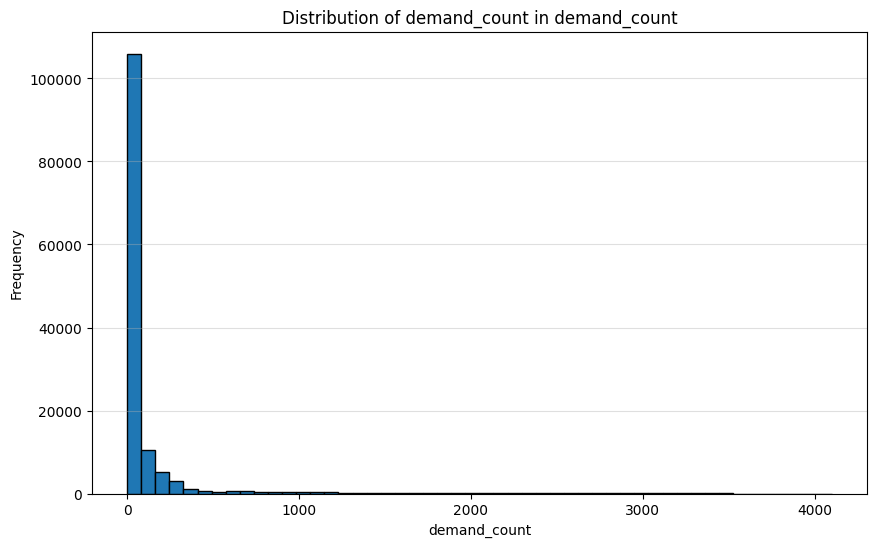

In [47]:
print("H3 r6 × 4h demand distribution:")
print(df_agg_add_weather["demand_count"].describe(percentiles=[.25, .5, .75, .95, .99]))

fig, ax = plot_demand_distribution(df_agg_add_weather["demand_count"])
plt.show()

`demand_count` is strongly right-skewed: median 11 pickups per cell/4h-bin, mean 108 (pulled up by a few very high-demand cell-hours, max 4,098), and 12.6% of cell-time combinations have zero demand after zero-filling. This skew is expected given H3 cells vary greatly in area type (downtown vs. residential) and should inform the choice of loss function / target transform in Task 3.

### Step 6: Calculate idle time
Idle time is the gap between when a taxi ends one trip and when it starts the next trip. It represents the time a driver is available but not carrying a passenger.

In [48]:
# Idle time on a SLIM 3-column frame, not a full copy of df.
# A full df.sort_values() would duplicate the entire ~25-column frame in memory.
# idle only needs taxi_id + the two timestamps.
_idle = df[["taxi_id", "trip_start_timestamp", "trip_end_timestamp"]].sort_values(
    ["taxi_id", "trip_start_timestamp"]
)
_idle["prev_trip_end"] = _idle.groupby("taxi_id", observed=True)["trip_end_timestamp"].shift(1)
_idle["idle_seconds"] = (
    _idle["trip_start_timestamp"] - _idle["prev_trip_end"]
).dt.total_seconds()

Note: Very large idle gaps are not real idle time. If a taxi ends a trip on Monday and starts again on Thursday, the gap would include off-shift time, not operational idling. Therefore, to get valid inter-trip gaps, we filter the idle time not longer than 4 hours.

In [49]:
# Valid inter-trip gaps only (0 to 4 hours).
valid_idle = _idle[_idle["idle_seconds"].between(0, 4 * 3600)].copy()

# Bring back the columns the Task 2 idle aggregates need. valid_idle is a row-subset
# of df, so the index aligns and this join is exact (no data invented).
valid_idle = valid_idle.join(
    df[["trip_id", "day_of_week", "hour", "h3_r6", "time_1h", "time_4h", "pickup_community_area"]]
)

# Average idle time per taxi
avg_idle_per_taxi = valid_idle.groupby("taxi_id", observed=True)["idle_seconds"].mean()

print(f"valid_idle: {len(valid_idle):,} rows")

valid_idle: 12,053,237 rows


In [50]:
# Calculate average idle time across spatial and temporal units
idle_by_location_time = (
    valid_idle
    .groupby(["h3_r6", "time_4h"])["idle_seconds"]
    .mean()
    .reset_index()
    .rename(columns={"h3_r6": "location_id", "time_4h": "timestamp", "idle_seconds": "avg_idle_seconds"})
)
idle_by_location_time

,location_id,timestamp,avg_idle_seconds
0,862664197ffffff,2024-01-01 08:00:00,1200.0
1,862664197ffffff,2024-01-01 12:00:00,1800.0
2,862664197ffffff,2024-01-01 16:00:00,1200.0
3,862664197ffffff,2024-01-01 20:00:00,3000.0
4,862664197ffffff,2024-01-02 00:00:00,8100.0
...,...,...,...
113683,86275936fffffff,2026-03-31 04:00:00,2700.0
113684,86275936fffffff,2026-03-31 08:00:00,3060.0
113685,86275936fffffff,2026-03-31 12:00:00,2700.0
113686,86275936fffffff,2026-03-31 16:00:00,1620.0


### Save relevant files for following tasks

In [53]:
# Check if there are any days without any demand in df
all_dates = pd.to_datetime(df["date"]).dt.normalize()
full_range = pd.date_range(all_dates.min(), all_dates.max(), freq="D")
present = set(all_dates.unique())
missing = [d for d in full_range if d not in present]
print(f"Date span: {all_dates.min().date()} → {all_dates.max().date()}")
print(f"Calendar days in span: {len(full_range)} | present: {len(present)} | missing: {len(missing)}")
if missing:
    print("Missing dates:", [str(d.date()) for d in missing[:20]])

Date span: 2024-01-01 → 2026-04-01
Calendar days in span: 822 | present: 822 | missing: 0


In [54]:
import pathlib

PROCESSED = pathlib.Path("../processed")
PROCESSED.mkdir(exist_ok=True)

# city-level temporal aggregates
agg_city_dow_hour = (
    df.groupby(["day_of_week", "hour"], observed=True)
      .agg(n_trips         =("trip_id",      "size"),
           mean_trip_miles =("trip_miles",   "mean"),
           mean_trip_secs  =("trip_seconds", "mean"),
           mean_trip_total =("trip_total",   "mean"))
      .reset_index()
)

_ym = df["trip_start_timestamp"].dt.to_period("M").dt.to_timestamp()
agg_city_month = (
    df.assign(month_start=_ym)
      .groupby("month_start", observed=True)
      .agg(n_trips=("trip_id", "size"))
      .reset_index()
)

idle_city_dow_hour = (
    valid_idle.groupby(["day_of_week", "hour"], observed=True)
              .agg(mean_idle_secs=("idle_seconds", "mean"),
                   n             =("idle_seconds", "size"))
              .reset_index()
)

# spatial choropleth aggregates (summed over all time) 
agg_h3r4_total = df.groupby("h3_r4", observed=True).agg(n_trips=("trip_id", "size")).reset_index()
agg_h3r5_total = df.groupby("h3_r5", observed=True).agg(n_trips=("trip_id", "size")).reset_index()
agg_h3r6_total = df.groupby("h3_r6", observed=True).agg(n_trips=("trip_id", "size")).reset_index()
agg_h3r7_total = df.groupby("h3_r7", observed=True).agg(n_trips=("trip_id", "size")).reset_index()
agg_h3r8_total = df.groupby("h3_r8", observed=True).agg(n_trips=("trip_id", "size")).reset_index()
agg_ca_total = (
    df["pickup_community_area"]
      .value_counts(dropna=True)
      .reset_index()
      .rename(columns={"count": "n_trips"})
)

# point coordinates for GMM / KDE (+ 2.1 baseline distributions) 
slim_trips = df[[
    "pickup_centroid_latitude", "pickup_centroid_longitude",
    "trip_miles", "trip_seconds", "trip_total",
]].copy()

# spatio-temporal aggregate (finest key -> collapses both ways) 
agg_h3r6_dow_hour = (
    df.groupby(["h3_r6", "day_of_week", "hour"], observed=True)
      .agg(n_trips=("trip_id", "size"))
      .reset_index()
)

# Origin-Destination flows at Community Area level 
agg_od_ca = (
    df[["pickup_community_area", "dropoff_community_area", "trip_miles", "trip_total"]]
      .dropna(subset=["pickup_community_area", "dropoff_community_area"])
      .groupby(["pickup_community_area", "dropoff_community_area"], observed=True)
      .agg(n_trips         =("trip_miles",  "size"),
           mean_trip_miles =("trip_miles",  "mean"),
           mean_trip_total =("trip_total",  "mean"))
      .reset_index()
)

# denominators: distinct dates, for honest "mean demand per day" 
calendar_counts = (
    df.groupby("day_of_week", observed=True)["date"].nunique()
      .reset_index().rename(columns={"date": "n_dates"})
)

# assemble everything (new aggregates + already-built datasets) 
idle_per_trip = valid_idle[[
    "trip_id", "time_1h", "time_4h", "h3_r6", "pickup_community_area", "idle_seconds",
]].copy()

# Trip-level export for resolution sensitivity in 2.7
df_trips_full = df[[
    "trip_id", "trip_start_timestamp",
    "h3_r4", "h3_r5", "h3_r6", "h3_r7", "h3_r8",
    "pickup_community_area", "pickup_census_tract",
    "pickup_centroid_latitude", "pickup_centroid_longitude",
    "trip_miles", "trip_seconds", "trip_total",
    "fare", "tips", "payment_type", "company",
    "avg_speed_mph", "price_per_mile",
]].copy()

datasets = {
    "agg_city_dow_hour":  agg_city_dow_hour,
    "agg_city_month":     agg_city_month,
    "idle_city_dow_hour": idle_city_dow_hour,
    "agg_h3r4_total":     agg_h3r4_total,
    "agg_h3r5_total":     agg_h3r5_total,
    "agg_h3r6_total":     agg_h3r6_total,
    "agg_h3r7_total":     agg_h3r7_total,
    "agg_h3r8_total":     agg_h3r8_total,
    "agg_ca_total":       agg_ca_total,
    "slim_trips":         slim_trips,
    "agg_h3r6_dow_hour":  agg_h3r6_dow_hour,
    "calendar_counts":    calendar_counts,
    "agg_od_ca":          agg_od_ca, # origin-destination flows at community area level
    "idle_per_trip":      idle_per_trip,
    "df_weather_hours":   df_weather_hours,
    "df_weather_4hours":  df_weather_4hours,
    "df_agg_r6_4h":       df_agg_add_weather,
    "df_trips_full":      df_trips_full
}

for name, obj in datasets.items():
    path = PROCESSED / f"{name}.parquet"
    obj.to_parquet(path, index=False)
    size_mb = path.stat().st_size / 1e6
    print(f"{name:<22} {obj.shape[0]:>10,} rows × {obj.shape[1]:>2} cols   {size_mb:>7.1f} MB")

print(f"\ntotal distinct dates: {int(df['date'].nunique()):,}")
print(f"Saved to: {PROCESSED.resolve()}")


agg_city_dow_hour             168 rows ×  6 cols       0.0 MB
agg_city_month                 28 rows ×  2 cols       0.0 MB
idle_city_dow_hour            168 rows ×  4 cols       0.0 MB
agg_h3r4_total                  4 rows ×  2 cols       0.0 MB
agg_h3r5_total                  8 rows ×  2 cols       0.0 MB
agg_h3r6_total                 27 rows ×  2 cols       0.0 MB
agg_h3r7_total                128 rows ×  2 cols       0.0 MB
agg_h3r8_total                475 rows ×  2 cols       0.0 MB
agg_ca_total                   77 rows ×  2 cols       0.0 MB
slim_trips             14,382,862 rows ×  5 cols     103.5 MB
agg_h3r6_dow_hour           4,408 rows ×  4 cols       0.0 MB
calendar_counts                 7 rows ×  2 cols       0.0 MB
agg_od_ca                   5,705 rows ×  5 cols       0.1 MB
idle_per_trip          12,053,237 rows ×  6 cols     548.8 MB
df_weather_hours           19,728 rows ×  7 cols       0.2 MB
df_weather_4hours           4,932 rows ×  7 cols       0.1 MB
df_agg_r

In [55]:
import pyarrow as pa
import pyarrow.parquet as pq
import pathlib, gc

PROCESSED = pathlib.Path("../processed")
PROCESSED.mkdir(exist_ok=True)
path = PROCESSED / "df_trips_full.parquet"

print(f"df memory: {df.memory_usage(deep=True).sum()/1e9:.2f} GB, {len(df):,} rows")

chunk_size = 1_000_000
writer = None
try:
    for start in range(0, len(df), chunk_size):
        chunk = df.iloc[start:start + chunk_size]
        table = pa.Table.from_pandas(chunk, preserve_index=False)
        if writer is None:
            writer = pq.ParquetWriter(path, table.schema)
        writer.write_table(table)
        del chunk, table
        gc.collect()
        print(f"  wrote rows {start:,}–{min(start+chunk_size, len(df)):,}")
finally:
    if writer is not None:
        writer.close()

size_gb = path.stat().st_size / 1e9
print(f"\nSaved {path.name}: {size_gb:.2f} GB on disk")

df memory: 4.85 GB, 14,382,862 rows
  wrote rows 0–1,000,000
  wrote rows 1,000,000–2,000,000
  wrote rows 2,000,000–3,000,000
  wrote rows 3,000,000–4,000,000
  wrote rows 4,000,000–5,000,000
  wrote rows 5,000,000–6,000,000
  wrote rows 6,000,000–7,000,000
  wrote rows 7,000,000–8,000,000
  wrote rows 8,000,000–9,000,000
  wrote rows 9,000,000–10,000,000
  wrote rows 10,000,000–11,000,000
  wrote rows 11,000,000–12,000,000
  wrote rows 12,000,000–13,000,000
  wrote rows 13,000,000–14,000,000
  wrote rows 14,000,000–14,382,862

Saved df_trips_full.parquet: 1.11 GB on disk


### Summary of datasets created in 1.6

Section 1.6 transforms the cleaned trip-level data into the demand datasets used in Tasks 2 and 3.
The trip-level frame `df` (hard exclusions applied, pickup coordinates present) is the source for
everything below; all outputs are saved to `../processed/` as parquet.

**Trip-level source**

| Object | Grain | Notes |
|---|---|---|
| `df` | one row per trip | Adds H3 cell IDs (`h3_r4`-`h3_r8`) and time buckets (`time_1h`, `time_4h`, `time_8h`, `time_1d`) to the 1.5 features. Saved as `df_trips_full.parquet`. |

**Canonical modeling dataset**

| Object | Grain | Key columns |
|---|---|---|
| `df_agg_add_weather` | H3 r6 × 4-hour bin | `demand_count` (zero-filled), `avg_trip_miles/seconds/total`, `n_unique_taxis`, merged 4-hour weather. Saved as `df_agg_r6_4h.parquet`. The starting point for Task 3. |

**Descriptive aggregates (for Task 2)**

| Object | Grain | Key columns |
|---|---|---|
| `agg_city_dow_hour` | day-of-week × hour | `n_trips`, `mean_trip_miles/secs/total` |
| `agg_city_month` | calendar month | `n_trips` |
| `idle_city_dow_hour` | day-of-week × hour | `mean_idle_secs`, `n` |
| `agg_h3r4_total` … `agg_h3r8_total` | H3 cell (per resolution) | `n_trips` |
| `agg_ca_total` | community area | `n_trips` |
| `agg_h3r6_dow_hour` | H3 r6 × day-of-week × hour | `n_trips` |
| `slim_trips` | trip | pickup coordinates + `trip_miles/seconds/total` (for GMM/KDE) |
| `calendar_counts` | day-of-week | `n_dates` is denominator for mean-per-day |
| `idle_per_trip` | trip (with valid idle gap) | `idle_seconds` + join keys |

**Key conventions**

- **`demand_count` vs `n_trips`:** `df_agg_add_weather` uses zero-filled `demand_count` (modeling); descriptive aggregates use observed-only `n_trips`.
- **Soft exclusions** apply to characteristic means only (zero-mile dropped from distance, zero-second from duration, `trip_total > 200` from fare) — all such trips still count in `demand_count`/`n_trips`.
- **Mean per day/hour** = summed `n_trips` ÷ relevant date count from `calendar_counts` (counts zero-demand periods correctly).
- **H3 cells are a uniform geometric grid**, not city districts; r6 (~3 km) is canonical. Census tracts excluded (55.65% missing, see 1.3).

## 1.7 Summary

#### 1.1 Dataset Overview

Key findings:
- `pickup_census_tract`: **55.65% missing** - not suitable as the main spatial unit
- `pickup_community_area`: **2.79% missing** - reliable, used as the primary spatial unit
- Pickup coordinates (lat/lon): **2.74% missing** - reliable, used for H3 hexagons
- All other core columns (timestamps, trip miles, trip total) have <1% missing

This part establishes which columns can actually be used for aggregation without losing large portions of data. Census Tracts are immediately flagged as unreliable for absolute demand estimates.



#### 1.2 Syntactical Cleaning

Key findings: No fully duplicated rows or duplicate Trip IDs. A small number of numeric columns gained additional NaNs after type conversion (e.g. `trip_total` +1,783 rows)


#### 1.3 Missing Value Strategy

Key findings: 
- Missing `pickup_community_area` is spread evenly across hours (+/– a few % per hour) and months (2.49%-3.01%) - removing these rows will not distort temporal patterns
- Small taxi companies show higher missing rates but represent a negligible share of total trips
- `pickup_community_area` and pickup coordinates are missing for virtually the same rows (only 7,566 rows differ)


#### 1.4 Semantic Validation & Outlier Handling

Key findings & decisions:

| Flag | Rows affected | Decision |
|---|---|---|
| `end_before_start` (timestamp error) | 98 | Hard exclude |
| `extreme_seconds` (> 3 hours) | ~12,000 (0.08%) | Hard exclude - median duration 9.8h, not real taxi trips |
| `extreme_miles` (> 100 miles) | ~1,200 (0.01%) | Hard exclude - these distances are too long for a taxi trip|
| `invalid_seconds` (= 0 s) | ~202,000 (1.36%) | Soft - still count as pickups, excluded from duration features |
| `zero_miles` (= 0 mi) | ~1.3M (8.75%) | Soft - still count as pickups, excluded from distance features |
| `extreme_total` (> $200) | ~9,500 (0.06%) | Soft - excluded from revenue aggregations only |

Total hard exclusions: ~13,000 rows (0.09%). **99.91% of trips are retained for demand counting.**

Timestamps are rounded to 15-min intervals, causing a structural ~30-min discrepancy with `trip_seconds`. This is expected and not treated as an error. All pickup coordinates fall within Chicago's bounding box.

Demand counts must not drop valid pickup events. Separating hard from soft exclusions ensures that outlier removal only affects the specific features they distort, not the overall trip count.


#### 1.5 Feature Engineering & External Enrichment

**Features created:**

| Group | Columns | Purpose |
|---|---|---|
| Temporal | `hour`, `day_of_week`, `is_weekend`, `month`, `date` | Core demand predictors and time-bucket join keys |
| Operational | `avg_speed_mph` (capped 80 mph, min 60s trips) | Fleet utilisation proxy; ~40% of trips are below 2 mph due to congestion/waiting |
| Monetary | `price_per_mile`, `price_per_minute` | Revenue potential per area; not used as demand predictors |

**Weather data (Open-Meteo, Chicago centroid, 2024–2026):**
- Hourly: temperature, precipitation, rain, snowfall, wind speed, WMO code → joined to 1h and 4h demand tables
- Daily: mean temp, sunshine hours, precipitation sum, max wind → joined to daily aggregations
- One city-centre station used (9km model resolution makes multi-station interpolation unnecessary at 4h granularity)


#### 1.6 Spatial & Temporal Aggregation

**Aggregations produced:** 7 spatial × 4 temporal = 28 combinations (h3 r4-r8, Community Area, Census Tract × 1h, 4h, 8h, 1d).

**Primary dataset chosen: H3 resolution 6 × 4-hour buckets**

**Sparsity findings (zero-demand cells after fill):**

| Resolution | Zero cells | Notes |
|---|---|---|
| H3 r6 × 4h | Very low | **Chosen as primary** |
| Community Area × 4h / 8h / 1d  | Moderate | More zero cells |
| H3 r7/r8 × 1h | High-Very high | Too sparse for reliable modeling |
| Census Tract × any | Extremely high | Sensitivity analysis only |

Excluding the 0-5 AM window (near-zero demand universally) meaningfully reduces sparsity for all 1h datasets and the 0 AM bucket for 4h datasets.

**Demand distribution:** Strongly right-skewed, most (location, time) cells have low or zero demand. A small number of peak cells (high-demand areas, peak hours) have very high counts. The median is far below the mean.

**Idle time:** Calculated as the gap between consecutive trips per taxi, capped at 4 hours to exclude off-shift gaps. Aggregated by H3 r6 and 4h bucket. High idle = local over-supply or weak demand.

This step produces the actual modeling input. The choice of H3 r6 × 4h balances spatial granularity (~10 km² hexagons), temporal resolution, and manageable sparsity. Explicit zero-demand cells are required so that models learn the absence of demand, not just its presence. Idle time feeds into Task 2 as a supply-pressure feature and into Task 3 for repositioning analysis.
